# To perform and visualize analyses online 

## Before the experiment: get everything ready 

### imports

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import hydra
from hydra.utils import get_original_cwd
import os
from omegaconf import DictConfig, OmegaConf
from dataclasses import dataclass
from typing import List, Dict, Any

from IPython.display import display



In [7]:
# Load config
import sys
import os
from pathlib import Path


# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

# Import Hydra config utilities
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize

# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"config")
print(f"Config path: {config_path}")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")
print(OmegaConf.to_yaml(cfg))



home directory: /gpfs01/euler/User/ssuhai
Config path: GitRepos/simulation_closed_loop/config
Configuration loaded successfully:
data_subfolders:
  day: 20250903
  experiment: 1
DJ:
  username: ssuhai
  userinfo:
    experimenter: closedlooptest
    animal_loc: 1
    region_loc: 2
    field_loc: 3
    stimulus_loc: 4
    cond1_loc: 5
    data_dir: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_meis_1
  table_parameters:
    PreprocessParams:
    - preprocess_id: 1
      fs_resample: 60
      stim_names:
      - gChirp
      - lChirp
      - movingbar
      - densenoise
    - preprocess_id: 2
      window_length: 60
      poly_order: 3
      non_negative: 1
      subtract_baseline: 0
      standardize: 1
      stim_names:
      - mouse_cam
    Stimulus:
      noise:
        stim_name: densenoise
        stim_family: noise
        pix_n_x: 20
        pix_n_y: 15
        skip_duplicates: true
        pix_scale_x_um: 40
        pix_scale_y_um: 40
        fra

In [8]:
from simulations.loop_components.dj_wrappers import (DJTableHolder,Preprocessor,QualityAndTypeWrapper,STAWrapper,RandomSeedMEIWrapper,
                                                     show_all_rois_plot)
from simulations.loop_components.recording_file_copier import copy_rec_files,create_directory_structure
from simulations.loop_components.stimulus import create_single_mei_avis_and_metadata
from simulations.loop_components.utils import log

### Create processing components (connect them to DB)

In [9]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

dj_table_holder = DJTableHolder(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                data_subfolders=cfg.data_subfolders, # type: ignore


                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore
                )



In [10]:
# # # Load config and tables
# dj_table_holder.load_config()
# dj_table_holder.load_tables()
# # # print(" loaded and configured successfully")
# # # # dj_table_holder.clear_tables("experiment")

dj_table_holder.setup()



[2025-09-03 16:09:33,370][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-09-03 16:09:33,428][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop


/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:195: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:203: UserWarning: Stimulus offset not set. Assuming 0 offset. This is incorrect for the standard dense noise stimulus.
  warnings.warn(
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:112: UserWarning: Values for ['bardx', 'bardy', 'velumsec', 'tmovedurs'] in `stim_dict` for stimulus `movingbar` are None. This may cause problems downstream.
  warnings.warn(f'Values for {missing_info} in `stim_dict` for stimulus `{stim_name}` are None. '
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/core/stimulus.py:39: UserWarning: Number of triggers in trial_info=8 must match ntrigger_rep=1.
  warnings.warn(msg)


preprocessing params:
 [{'preprocess_id': 1, 'fs_resample': 60, 'stim_names': ['gChirp', 'lChirp', 'movingbar', 'densenoise']}, {'preprocess_id': 2, 'window_length': 60, 'poly_order': 3, 'non_negative': 1, 'subtract_baseline': 0, 'standardize': 1, 'stim_names': ['mouse_cam']}]
Saving classifier to /gpfs01/euler/User/ssuhai/datajoint/rgc_classifier/rgc_classifier.pkl
Done setting up!


In [11]:
preprocessor = Preprocessor(dj_table_holder=dj_table_holder)


quality_type_analysis_wrapper = QualityAndTypeWrapper(
    dj_table_holder=dj_table_holder,)

sta_wrapper = STAWrapper(
    dj_table_holder=dj_table_holder,)

random_seed_mei_wrapper = RandomSeedMEIWrapper(
    dj_table_holder=dj_table_holder,
    cfg=cfg,
    seeds=[111,222]
)

## During the experimet

### Move files from server to the repo 

In [14]:
create_directory_structure(base_directory= cfg.DJ.userinfo.data_dir,
                           date=  cfg.data_subfolders.day, 
                           experiment = cfg.data_subfolders.experiment)

copy_rec_files(
    recording_files_dir=cfg.paths.recording_files_dir,  # type: ignore
    destination_base=cfg.DJ.userinfo.data_dir,  # type: ignore
    date=cfg.data_subfolders.day,  # type: ignore
    experiment=cfg.data_subfolders.experiment,  # type: ignore
    full_dummy_ini_dir= os.path.join(cfg.paths.repo_directory, cfg.paths.dummy_ini_dir),  # type: ignore
)

COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL4_MB.smh to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_meis_1/20250903/1/Raw/M1_RR_GCL4_MB_iter0.smh
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL4_DN.smh to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_meis_1/20250903/1/Raw/M1_RR_GCL4_DN_iter0.smh
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL4_MB.smp to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_meis_1/20250903/1/Raw/M1_RR_GCL4_MB_iter0.smp
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL4_MC18.smh to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_meis_1/20250903/1/Raw/M1_RR_GCL4_MC18_iter0.smh
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL4_MC18.smp to /gpfs01/euler/User/

### Preprocessing

In [15]:
preprocessor.upload_iteration_metadata()

[2025-09-03 17:14:30,731][WARNING]: MySQL server has gone away. Reconnecting to the server.


Scanning for experimenter: closedlooptest
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_meis_1/20250903/1
		header_name: 20250903_left.ini
		Adding: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 9, 3, 0, 0), 'exp_num': 1}


OpticDisk: 100%|██████████| 1/1 [00:00<00:00, 28.11it/s]


Found 4 files in 1 fields for key={'experimenter': 'closedlooptest', 'date': datetime.date(2025, 9, 3), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'GCL4', 'region': 'RR', 'cond1': 'iter0', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 9, 3), 'exp_num': 1, 'raw_id': 1}`


Processes: 100%|██████████| 6/6 [00:07<00:00,  1.30s/it]


In [16]:
missing_keys = dj_table_holder("RoiMask")().list_missing_field()
if len(missing_keys) == 1:
    field_key = missing_keys[0]
    print(f"Missing field key found: {field_key}")
elif len(missing_keys) > 1:
    raise ValueError(f"Multiple missing fields found: {missing_keys}")
else:
    print("No missing fields found, using the last field key.")
    all_field_key = dj_table_holder("Field")().proj().fetch(as_dict=True)
    field_key = all_field_key[-1]
    print(f"Field key: {field_key}")

Missing field key found: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 9, 3), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL4', 'region': 'RR', 'cond1': 'iter0'}


In [17]:
# compute 
preprocessor.add_iteration_roi_mask(field_key=field_key)
preprocessor.add_iteration_rois()
preprocessor.add_iteration_traces()


field_key: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 9, 3), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL4', 'region': 'RR', 'cond1': 'iter0'} 
pres_keys: [{'experimenter': 'closedlooptest', 'date': datetime.date(2025, 9, 3), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL4', 'region': 'RR', 'cond1': 'iter0', 'stim_name': 'densenoise', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 9, 3), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL4', 'region': 'RR', 'cond1': 'iter0', 'stim_name': 'gChirp', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 9, 3), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL4', 'region': 'RR', 'cond1': 'iter0', 'stim_name': 'mouse_cam', 'cond2': 'control'}, {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 9, 3), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL4', 'region': 'RR', 'cond1': 'iter0', 'stim_name': 'movingbar', 'cond2': 'control'}]
No ROI masks found for field: {'experimenter': 'c

Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().


Processes: 100%|██████████| 404/404 [00:00<00:00, 560.37it/s]


### qualty and RF

In [18]:
quality_type_analysis_wrapper.compute_analysis(
    field_key=field_key)

# filter 
passed_roi_ids_chirp_mb = quality_type_analysis_wrapper.get_roi_ids_passing_criterion(field_key=field_key,
    d_qi_min =cfg.quality_filtering["d_qi_min"],
    qidx_min=cfg.quality_filtering["chirp_qi_min"],
    celltypes=cfg.quality_filtering["celltypes"],
    classifier_confidence=cfg.quality_filtering["classifier_confidence"])
if len(passed_roi_ids_chirp_mb) == 0:
    raise ValueError("No ROIs passed the quality criterion for quality and type.")
print(f"{len(passed_roi_ids_chirp_mb)} ROIs passed quality chirp mb filtering: {passed_roi_ids_chirp_mb}")



Processes: 100%|██████████| 101/101 [00:00<00:00, 356.81it/s]
/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/classifier/rgc_classifier.py:402: UserWarning: Parallel processing not implemented!
  warnings.warn('Parallel processing not implemented!')
CelltypeAssignment: 100%|██████████| 1/1 [00:06<00:00,  6.20s/it]

Found 11 rois passing the criterion out of 101 rois.              (d_qi_min=0.6, chrip qidx_min=0.35, celltypes=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32], classifier_confidence=0.25)
11 ROIs passed quality chirp mb filtering: [18, 27, 36, 39, 57, 63, 66, 72, 75, 81, 96]


In [19]:
# sta 
sta_wrapper.compute_analysis(
    field_key=field_key,
    roi_id_subset=passed_roi_ids_chirp_mb,)


Processes: 100%|██████████| 11/11 [00:00<00:00, 38.58it/s]


In [20]:
assert (dj_table_holder("STA")().fetch("roi_id") == passed_roi_ids_chirp_mb).all(), "STA roi_id does not match passed roi_ids from quality and type filtering."

In [22]:
# filter
passed_roi_ids_sta = sta_wrapper.get_roi_ids_passing_criterion(field_key=field_key,
                                                               rf_qidx_min= 0.3)#cfg.quality_filtering["rf_qidx_min"])
if len(passed_roi_ids_sta) == 0:
    raise ValueError("No ROIs passed the quality criterion for STA.")
print(f"{len(passed_roi_ids_sta)} ROIs passed STA filtering with rf_qidx_min={cfg.quality_filtering["rf_qidx_min"]}: {passed_roi_ids_sta}")


7 ROIs passed STA filtering with rf_qidx_min=0.5: [18, 27, 39, 57, 63, 66, 75]


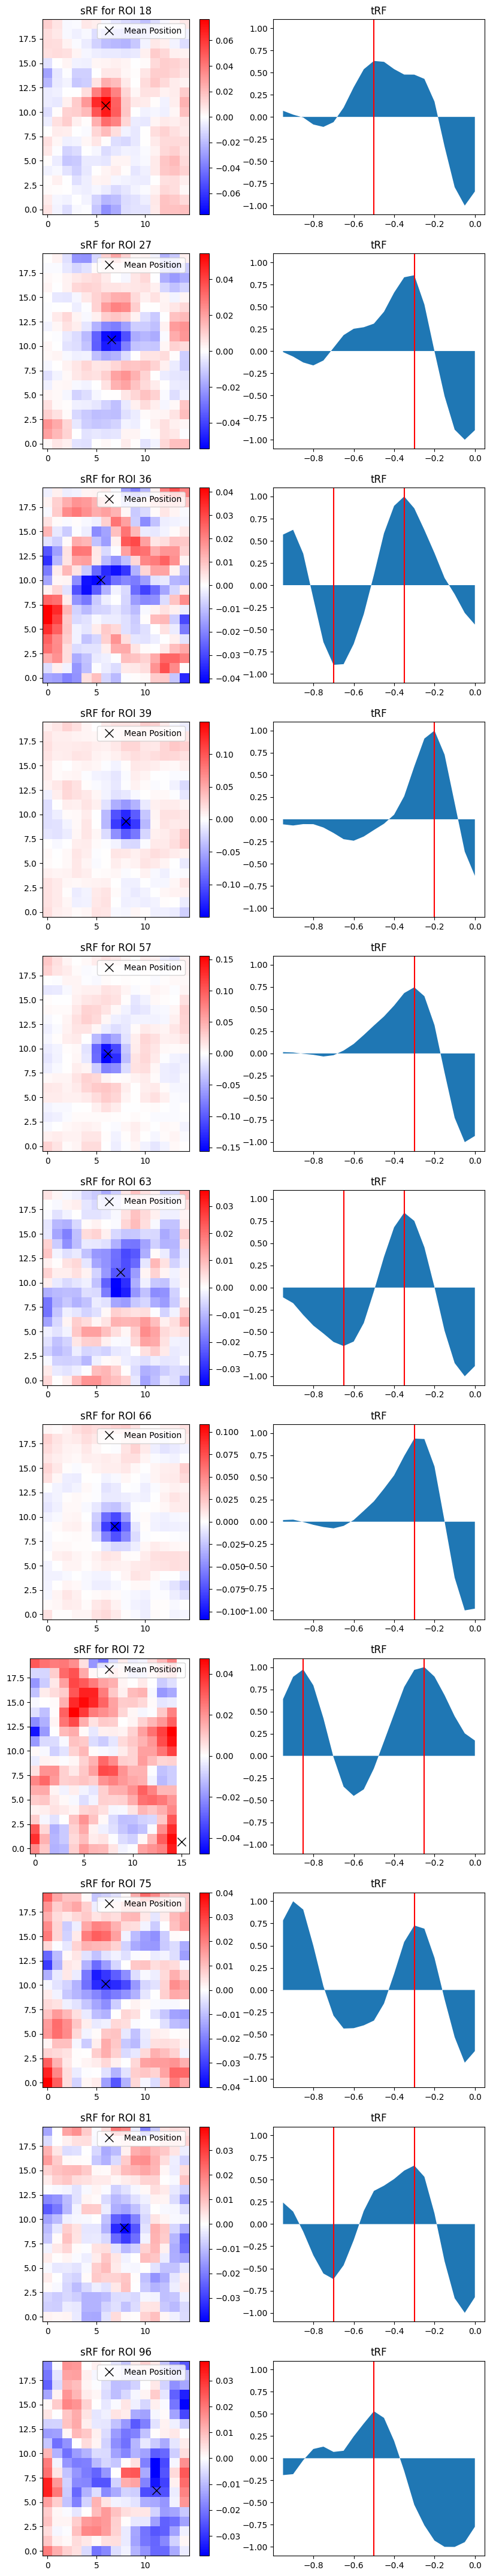

In [23]:
# inspect STAs
stafig,staax = show_all_rois_plot(dj_table_holder = dj_table_holder,wrapper=sta_wrapper,field_key=field_key)


### MEI

In [24]:
# compute
random_seed_mei_wrapper.compute_analysis(
    field_key=field_key,
    roi_id_subset=passed_roi_ids_sta,
    )

Processes: 100%|██████████| 7/7 [00:00<00:00, 97.96it/s]


Adding /gpfs01/euler/data/Resources/GitHub/external_repos/Cascade/ to sys.path


/gpfs01/euler/data/Resources/GitHub/external_repos/Cascade/cascade2p/cascade.py:556: SyntaxWarning: invalid escape sequence '\d'
  noise_level = int(re.findall("_NoiseLevel_(\d+)", model_path)[0])


	YAML reader installed (version 0.18.6).


2025-09-03 17:18:33.436550: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


...

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_correlation did not improve in the last 10 records. Best score: 0.110. Signaling Trainer to stop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃       DataLoader 1        ┃       DataLoader 2        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test_correlation      │    0.1589905470609665     │    0.10956306755542755    │    0.4321167767047882     │
│         test_loss         │     61.64945983886719     │     48.93467330932617     │     3.749039649963379     │
└───────────────────────────┴───────────────────────────┴───────────────────────────┴───────────────────────────┘

ValueError: Pipeline requires at least 6 neurons in readout got 5 with min_testset_correl of 0.3.              adjust quality_filtering[`min_testset_correl`] to 0.20021489483940977 to get this, then call                 random_seed_mei_wrapper.apply_quality_filter() and random_seed_mei_wrapper.mei_subanalysis() again.                    testset correlations are: {0: 0.6566773161469401, 1: 0.16428317366176926, 2: 0.5111446386701451, 3: 0.6577564541557018, 4: 0.20021489483940977, 5: 0.5983746754774285, 6: 0.31659210515697944}

In [25]:
random_seed_mei_wrapper.neuron_testset_correls


{0: 0.6566773161469401,
 1: 0.16428317366176926,
 2: 0.5111446386701451,
 3: 0.6577564541557018,
 4: 0.20021489483940977,
 5: 0.5983746754774285,
 6: 0.31659210515697944}

In [38]:
seed_train_val_test_correls = {
    "1000": [0.1589905470609665,0.10956306755542755,0.4321167767047882],
    "0": [0.1390458345413208,0.14123989641666412, 0.4108469784259796],
    "3000": [0.1691277027130127, 0.13594025373458862, 0.4126817584037781],
    "4000":  [0.14241282641887665, 0.129250630736351, 0.4323568642139435],
    "2000": [0.16710656881332397,0.13003872334957123, 0.392547070980072]}

In [26]:
random_seed_mei_wrapper.quality_filtering["min_testset_correl"] = 0

In [27]:
random_seed_mei_wrapper.apply_quality_filter()

Filtered neurons based on testset correlation: 7 -> 7


In [28]:
random_seed_mei_wrapper.mei_subanalysis()

Seed set to 111


Generating unstable MEIs for neurons (readout idx): [1, 4].


Seed set to 222


Done with meis in phase unstable.
Start decomposing ...
Decomposing MEIs for neuron (readout idx) 1 ...
changing norm of reconstruction 25.974449157714844 to match original mei norm 29.999998092651367
new reconstruction norm 29.999998092651367
Done reconstructing MEI for neuron (readout idx) 1, seed 111.
changing norm of reconstruction 25.49221420288086 to match original mei norm 30.000001907348633
new reconstruction norm 30.000001907348633
Done reconstructing MEI for neuron (readout idx) 1, seed 222.
Decomposing MEIs for neuron (readout idx) 4 ...
changing norm of reconstruction 26.286602020263672 to match original mei norm 30.000001907348633
new reconstruction norm 30.000001907348633
Done reconstructing MEI for neuron (readout idx) 4, seed 111.


Seed set to 111


changing norm of reconstruction 26.874147415161133 to match original mei norm 29.999996185302734
new reconstruction norm 29.999996185302734
Done reconstructing MEI for neuron (readout idx) 4, seed 222.
Generating stable MEIs for neurons (readout idx): [0, 2, 3, 5, 6].
Done with meis in phase stable.
Start decomposing ...
Decomposing MEIs for neuron (readout idx) 0 ...
changing norm of reconstruction 20.846481323242188 to match original mei norm 29.66799545288086
new reconstruction norm 29.667993545532227
Done reconstructing MEI for neuron (readout idx) 0, seed 111.
Decomposing MEIs for neuron (readout idx) 2 ...
changing norm of reconstruction 20.605396270751953 to match original mei norm 29.44940185546875
new reconstruction norm 29.449399948120117
Done reconstructing MEI for neuron (readout idx) 2, seed 111.
Decomposing MEIs for neuron (readout idx) 3 ...
changing norm of reconstruction 20.75098991394043 to match original mei norm 29.822370529174805
new reconstruction norm 29.82237052

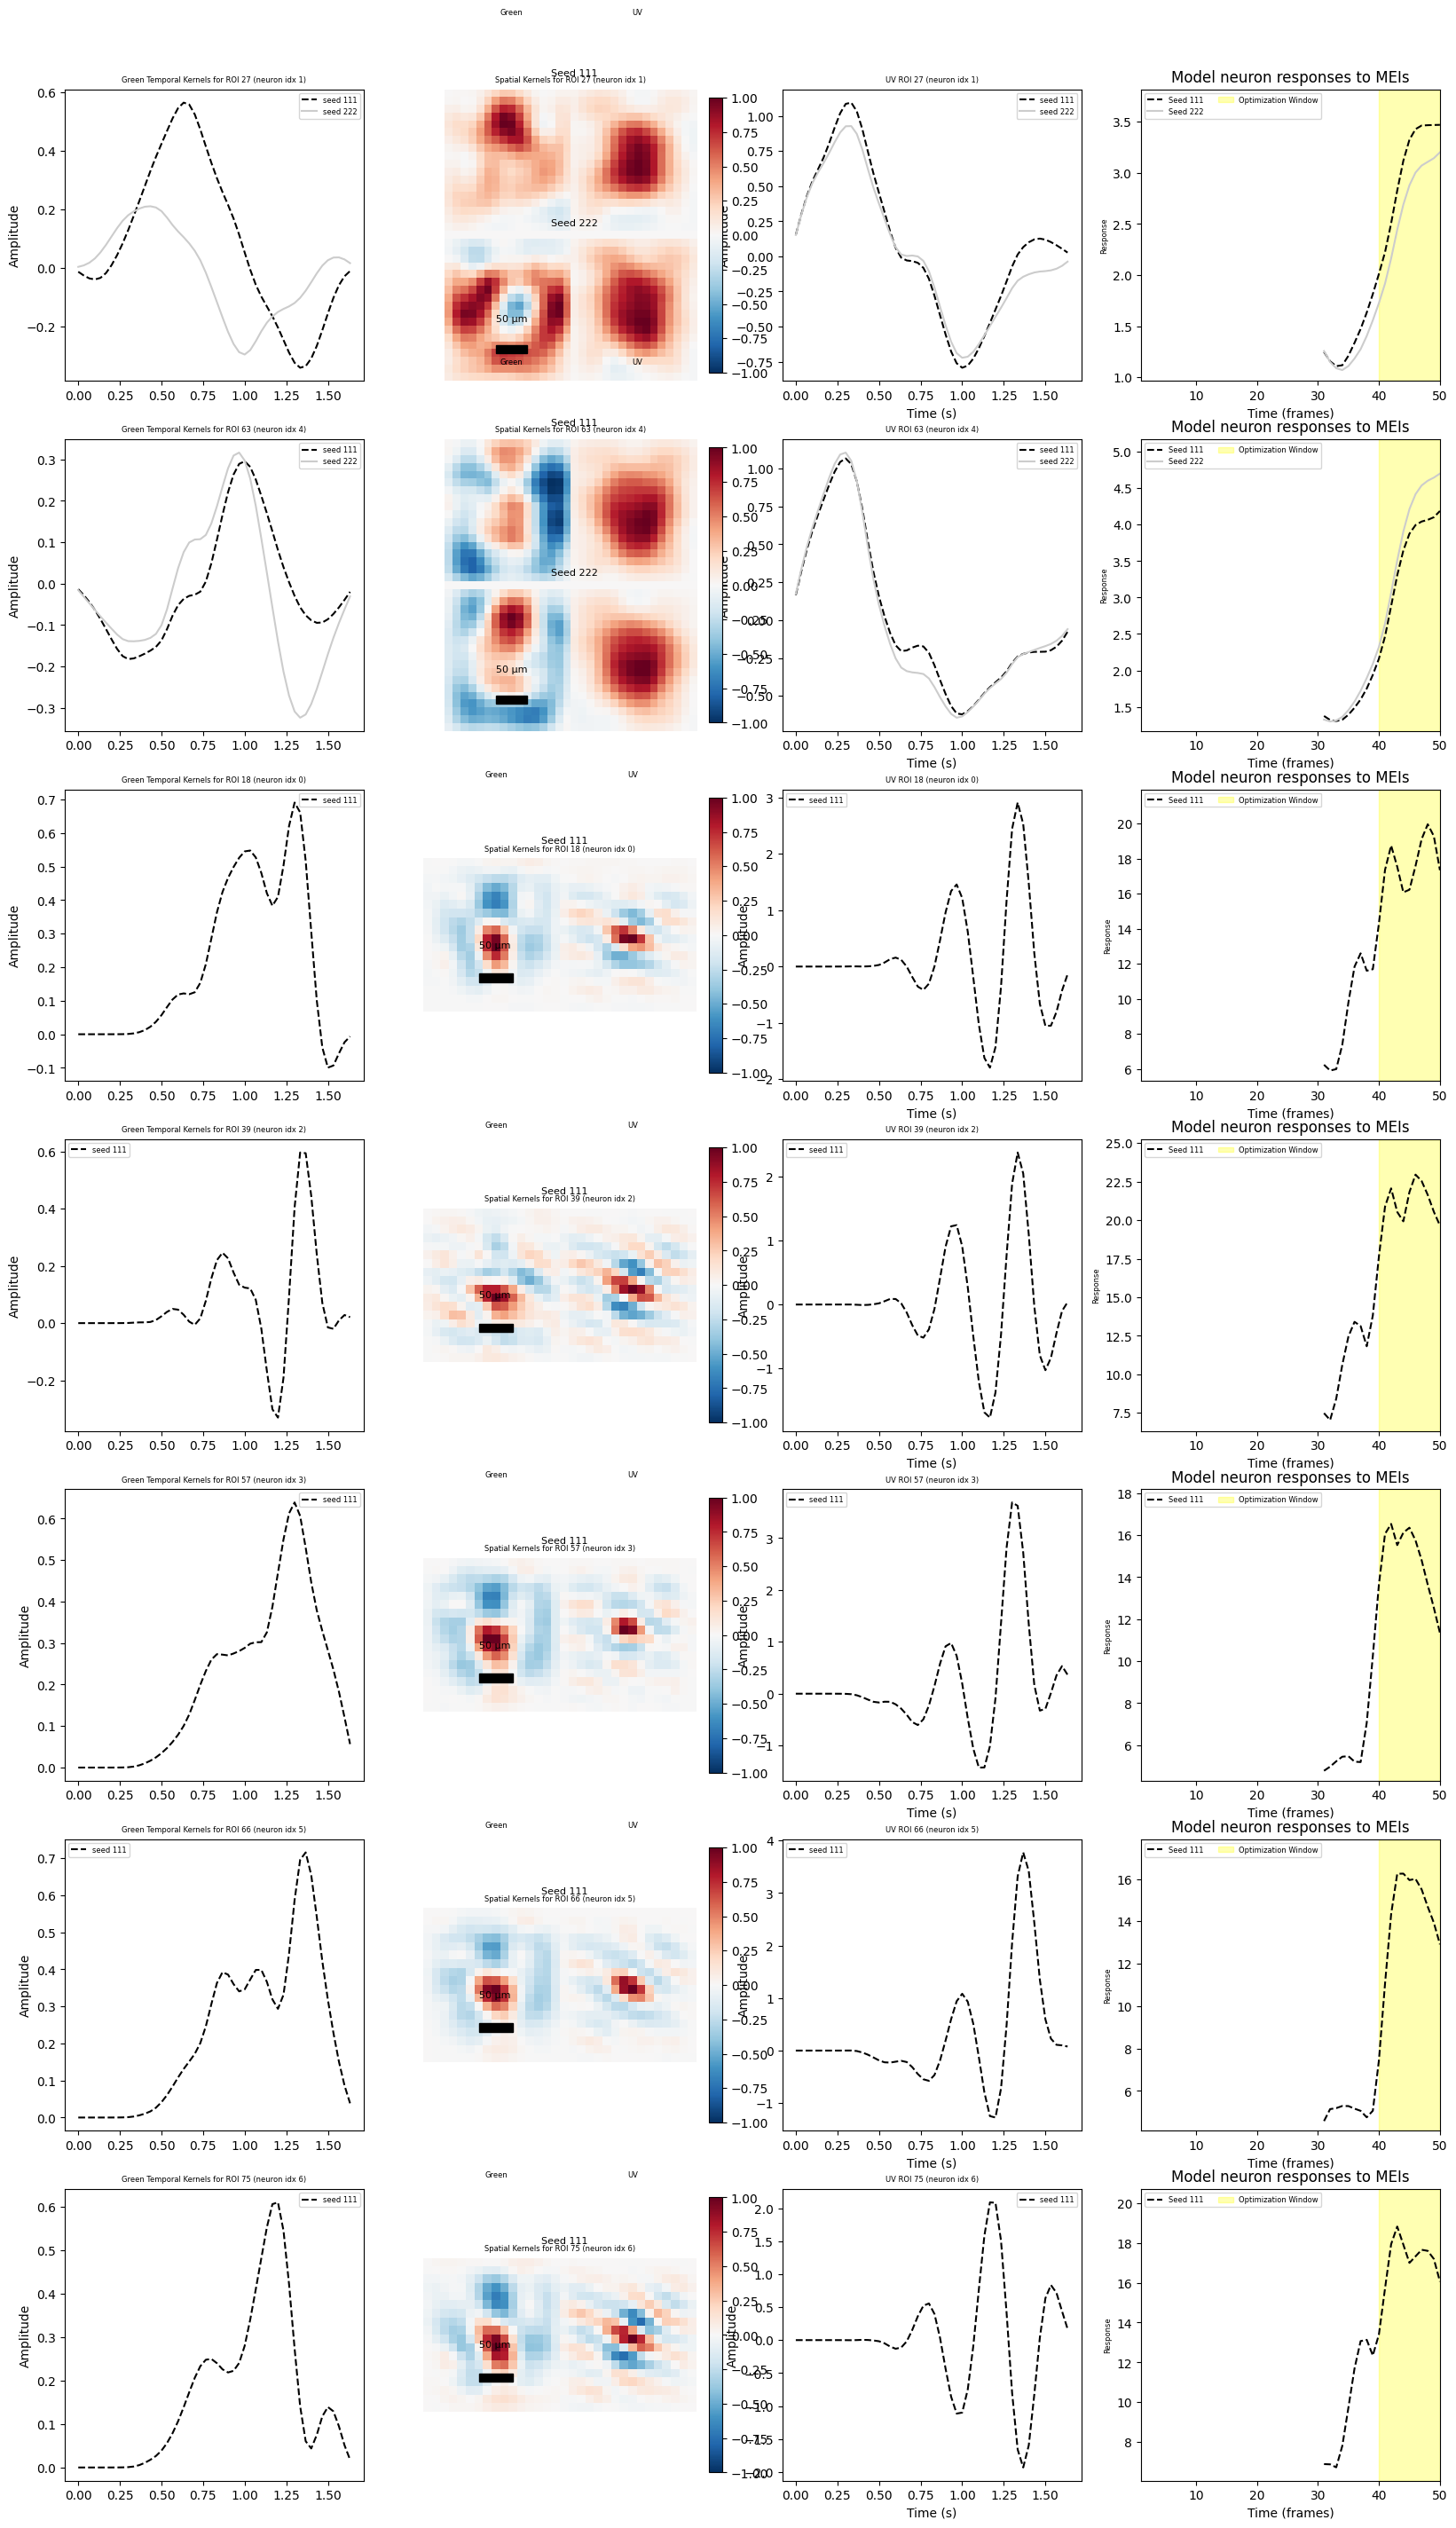

In [29]:
fig,axes = show_all_rois_plot(dj_table_holder=dj_table_holder,wrapper=random_seed_mei_wrapper,field_key=field_key)

In [ ]:
#random_seed_mei_wrapper.mei_generation_params["spatial_gaussian_kwargs"] ={'sigma': 0.35, 'kernel_size': 5, 'reflect_pad': True}
#random_seed_mei_wrapper.mei_subanalysis()

# The stimulus

### select roi ids and seds

In [30]:
[(row["roi_id"],row["seed"]) for _,row in  random_seed_mei_wrapper.mei_data_container[["roi_id","seed"]].iterrows()]

[(27, 111),
 (27, 222),
 (63, 111),
 (63, 222),
 (18, 111),
 (39, 111),
 (57, 111),
 (66, 111),
 (75, 111)]

In [48]:
roi_seed = [(27, 111),
 (27, 222),
 (63, 111),
 (63, 222),
 (18, 111),
 (39, 111),
 (57, 111),
 (66, 111),
 (75, 111)]
print(len(roi_seed))

9


In [45]:
roi_id2mei_id,roi_id2mei_info = random_seed_mei_wrapper.select_subset_of_meis_for_each_roi()

In [50]:
create_single_mei_avis_and_metadata(
    rois_seed=roi_seed,
    roi_id2mei_ids = roi_id2mei_id,    
    mei_data_container=random_seed_mei_wrapper.mei_data_container,
    stimulus_table=dj_table_holder("Stimulus")(),
    fit_gauss_2d_rf_table= dj_table_holder("FitGauss2DRF")(),
    abs_save_dir=cfg.paths.stimulus_output_dir,
)

Found 7 rois in the FitGauss2D table.
Initial roi_id order: [18, 27, 39, 57, 63, 66, 75].
Reordered roi_id order: [27, 57, 63, 66, 18, 39, 75].
Generated MEI presentation ordering: [['roi_27_seed_111', 'roi_27_seed_222', 'roi_39_seed_111', 'roi_63_seed_111', 'roi_66_seed_111', 'roi_75_seed_111'], ['roi_39_seed_111', 'roi_75_seed_111', 'roi_57_seed_111', 'roi_66_seed_111', 'roi_27_seed_111', 'roi_27_seed_222'], ['roi_27_seed_222', 'roi_63_seed_222', 'roi_66_seed_111', 'roi_75_seed_111', 'roi_39_seed_111', 'roi_63_seed_111'], ['roi_66_seed_111', 'roi_39_seed_111', 'roi_57_seed_111', 'roi_27_seed_222', 'roi_27_seed_111', 'roi_75_seed_111'], ['roi_27_seed_111', 'roi_75_seed_111', 'roi_57_seed_111', 'roi_39_seed_111', 'roi_18_seed_111', 'roi_63_seed_111'], ['roi_75_seed_111', 'roi_39_seed_111', 'roi_63_seed_111', 'roi_57_seed_111', 'roi_27_seed_111', 'roi_18_seed_111'], ['roi_75_seed_111', 'roi_57_seed_111', 'roi_18_seed_111', 'roi_27_seed_111', 'roi_39_seed_111', 'roi_27_seed_222']].
Creat

# Save data

In [39]:
# save data 
import datetime
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = os.path.join(cfg.paths.repo_directory,"data/pipeline_saved_data_during_experiment",timestamp)
random_seed_mei_wrapper.save_all_data_to_dir(save_dir=save_dir)

Saved raw session dict to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/pipeline_saved_data_during_experiment/20250903_181213/session_dict_raw.pkl
Saved MEI data container to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/pipeline_saved_data_during_experiment/20250903_181213/mei_data_container.pkl
Saved model state dict to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/pipeline_saved_data_during_experiment/20250903_181213/model_state_dict.pt
Saved full model to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/pipeline_saved_data_during_experiment/20250903_181213/model_full.pt
Saved metadata to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/pipeline_saved_data_during_experiment/20250903_181213/metadata.pkl


In [41]:
import pickle
with open(os.path.join(save_dir,"seed_train_val_test_correls.pkl"),"wb") as f:
    pickle.dump(seed_train_val_test_correls,f)

with open(os.path.join(save_dir,"roi_id2mei_id.pkl"),"wb") as f:
    pickle.dump(roi_id2mei_id,f)
with open(os.path.join(save_dir,"roi_id2mei_info.pkl"),"wb") as f:
    pickle.dump(roi_id2mei_info,f)

In [ ]:
#random_seed_mei_wrapper.load_all_data_from_dir(load_dir=save_dir)

# Clean up

In [ ]:
userinput = input("Cleanup? (y/n): ")
if userinput.lower() == 'y':
    dj_table_holder.clear_tables("all")


# shit goes south

In [ ]:
random_seed_mei_wrapper.mei_data_container["mei"].iloc[0].shape

In [34]:
all_roi_ids = (dj_table_holder("STA")() & field_key).fetch("roi_id")
import torch
import pandas as pd
#  dummy with seed 666 for all rois and random torch.tensor shape [2, 50, 18, 16] for each row
dummy_mei_data_container = pd.DataFrame({
    "roi_id": all_roi_ids,
    "seed": [666]*len(all_roi_ids),
    "mei_id": [f"roi_{roi_id}_seed_666" for roi_id in all_roi_ids],
    "mei": [torch.randn(2, 50, 18, 16) for _ in all_roi_ids],
})

In [35]:
roi_seed = [(row["roi_id"],row["seed"]) for _,row in  dummy_mei_data_container[["roi_id","seed"]].iterrows()]
print(roi_seed)

[(18, 666), (27, 666), (36, 666), (39, 666), (57, 666), (63, 666), (66, 666), (72, 666), (75, 666), (81, 666), (96, 666)]


In [36]:
dummy_roi_id2mei_id = {row["roi_id"]: [row["mei_id"]] for _,row in  dummy_mei_data_container[["roi_id","mei_id"]].iterrows()}
print(dummy_roi_id2mei_id)

{18: ['roi_18_seed_666'], 27: ['roi_27_seed_666'], 36: ['roi_36_seed_666'], 39: ['roi_39_seed_666'], 57: ['roi_57_seed_666'], 63: ['roi_63_seed_666'], 66: ['roi_66_seed_666'], 72: ['roi_72_seed_666'], 75: ['roi_75_seed_666'], 81: ['roi_81_seed_666'], 96: ['roi_96_seed_666']}


In [37]:
# create a 
create_single_mei_avis_and_metadata(
    rois_seed = roi_seed,
    roi_id2mei_ids = dummy_roi_id2mei_id,    
    mei_data_container=dummy_mei_data_container,
    stimulus_table=dj_table_holder("Stimulus")(),
    fit_gauss_2d_rf_table= dj_table_holder("FitGauss2DRF")(),
    abs_save_dir=cfg.paths.stimulus_output_dir,
)

Found 11 rois in the FitGauss2D table.
Initial roi_id order: [18, 27, 36, 39, 57, 63, 66, 72, 75, 81, 96].
Reordered roi_id order: [27, 72, 18, 96, 75, 81, 36, 39, 57, 63, 66].
Generated MEI presentation ordering: [['roi_27_seed_666'], ['roi_72_seed_666'], ['roi_18_seed_666'], ['roi_96_seed_666'], ['roi_75_seed_666'], ['roi_81_seed_666'], ['roi_36_seed_666'], ['roi_39_seed_666'], ['roi_57_seed_666'], ['roi_63_seed_666'], ['roi_66_seed_666']].
Creating MEI avi file for roi_18_seed_666 at /gpfs01/euler/data/Data/Suhai/stimuli_closed_loop/iter1/mei_roi_18_seed_666.avi.
Creating MEI avi file for roi_27_seed_666 at /gpfs01/euler/data/Data/Suhai/stimuli_closed_loop/iter1/mei_roi_27_seed_666.avi.
Creating MEI avi file for roi_36_seed_666 at /gpfs01/euler/data/Data/Suhai/stimuli_closed_loop/iter1/mei_roi_36_seed_666.avi.
Creating MEI avi file for roi_39_seed_666 at /gpfs01/euler/data/Data/Suhai/stimuli_closed_loop/iter1/mei_roi_39_seed_666.avi.
Creating MEI avi file for roi_57_seed_666 at /gpf